# Advanced Disk Modeling

This tutorial builds on the fundamental disk modeling tutorial to show a parameter estimation for real data using MCMC---we use the affine-invariant ensemble sampler implementation of MCMC from [`emcee`](https://emcee.readthedocs.io/en/stable/) ([Foreman-Mackey+ 2012](https://arxiv.org/abs/1202.3665)).

The data used in this tutorial is HD 115600 in H-band polarimetry from the Gemini Planet Imager debris disk survey ([Esposito+ 2020](https://iopscience.iop.org/article/10.3847/1538-3881/ab9199/meta)), and is publicly available on the CANFAR archive ([Crotts+ 2025](https://iopscience.iop.org/article/10.3847/1538-4365/ad90a4/pdf)).

In [1]:
from astropy.io import fits

import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np

import os
os.environ['XLA_PYTHON_CLIENT_MEM_FRACTION'] = '0.40'

jax.config.update("jax_enable_x64", True)

### Loading and Processing Files

For this tutorial using real data, we begin with starting parameter guesses from published literature values where possible. 

In [2]:
# GPI Image Initial Parameter Reference

# Name             Radius   Inclination  Position Angle Distance  Knots                                                  
# hd111161_H_pol    72.4         62.1        263.2        109.43      5
# hr4796a_H_pol     78.5         76.5         26.1         72.78      7
# hd115600_H_pol	46.0	     80.0	      27.5	      109.62	  5

row = {'Name': 'hd115600_H_pol', 'Radius': 51.0, 'Inclination': 85.0, "Position Angle": 17.5, "Distance": 109.62, "Knots": 5}


Filename: tutorial_images/hd115600_H_pol.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU     523   ()      
  1  SCI           1 ImageHDU       142   (281, 281, 4)   float32   
  2  DQ            3 ImageHDU        64   (281, 281, 2)   uint8   


Text(0.5, 1.0, 'HD 115600 Image from Fits File')

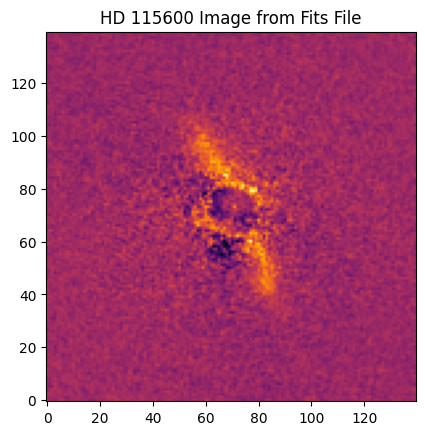

In [3]:
from grater_jax.optimization.optimize_framework import OptimizeUtils

fits_image_filepath = "tutorial_images/" + row['Name'] + ".fits"
hdul = fits.open(fits_image_filepath)

#Displays File Info
hdul.info()

# Gets Image
target_image = OptimizeUtils.process_image(hdul['SCI'].data[1,:,:], bounds=(70, 210, 70, 210))

# Displays Image
plt.imshow(target_image, origin='lower', cmap='inferno')
plt.title("HD 115600 Image from Fits File")

### Getting Optimal Disk Fit

In [4]:
from grater_jax.optimization.optimize_framework import Optimizer, OptimizeUtils
from grater_jax.disk_model.objective_functions import objective_model, objective_ll, objective_fit, Parameter_Index
from grater_jax.disk_model.SLD_ojax import ScatteredLightDisk
from grater_jax.disk_model.SLD_utils import *

#### Initializing Relevant Parameters

The disk fit begins with processing the target image and creating an error map, setting up the empirical PSF (if desired), and then initializing a disk model in the optimizer class with some starting parameters.

In [5]:
target_image = OptimizeUtils.process_image(hdul['SCI'].data[1,:,:], bounds=(70, 210, 70, 210))
err_map = OptimizeUtils.process_image(OptimizeUtils.create_empirical_err_map(hdul['SCI'].data[2,:,:]), bounds=(70, 210, 70, 210)) #, outlier_pixels=[(57, 68)]))

/home/blewis/anaconda3/envs/graterjax_new/lib/python3.10/site-packages/numpy/lib/_nanfunctions_impl.py:2019: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


In [6]:
scale_factor = 1
image = fits.open("tutorial_images/GPI_Hband_PSF.fits")[0].data[0,:,:]
scaled_image = (image[::scale_factor, ::scale_factor])[1::, 1::]
cropped_image = image[70:211, 70:211]
def safe_float32_conversion(value):
    try:
        return np.float32(value)
    except (ValueError, TypeError):
        print("This value is unjaxable: " + str(value))
emp_psf_image = np.nan_to_num(cropped_image)
emp_psf_image = np.vectorize(safe_float32_conversion)(emp_psf_image)

There are three functions used below that are worth pointing out:
1. `opt.inc_bound_knots` --- this uses the starting inclination guess to set bounds on the scattering angles used in the fit. A smaller range of scattering angles is visible for a face on disk than an edge on disk.
2. `opt.set_empirical_psf` --- this incorporates the empirical PSF, if you would like to use it.
3. `opt.initialize_knots` --- this function is **necessary** if you are using the spline SPF. It handles the relationship between the spline SPF values and the flux scaling, and other housekeeping tasks related to the spline.

In [7]:
start_disk_params = Parameter_Index.disk_params.copy()
start_spf_params = InterpolatedUnivariateSpline_SPF.params.copy()
start_psf_params = EMP_PSF.params.copy()
start_misc_params = Parameter_Index.misc_params.copy()

start_disk_params = Parameter_Index.disk_params.copy()
start_disk_params['sma'] = row["Radius"]
start_disk_params['inclination'] = row["Inclination"]
start_disk_params['position_angle'] = row["Position Angle"]

start_spf_params['num_knots'] = int(row["Knots"])

start_misc_params['distance'] = row["Distance"]

start_disk_params['x_center'] = target_image.shape[1]/2
start_disk_params['y_center'] = target_image.shape[0]/2

opt = Optimizer(ScatteredLightDisk, DustEllipticalDistribution2PowerLaws, InterpolatedUnivariateSpline_SPF, EMP_PSF,
                start_disk_params, start_spf_params, start_psf_params, start_misc_params)

opt.inc_bound_knots() # call this method only if you have a good predifined inclination, otherwise don't use it
opt.set_empirical_psf(emp_psf_image) # <-- Only necessary if you have an empirical_psf_image
opt.initialize_knots(target_image) # <-- This needs to be called first before any modeling or jit compiling if spline spf is being used

### JIT Compiling and Disk Modeling

If you would like to use the gradient functionality in your models, you need to explicitly compile the gradient for the JIT compilation using `opt.jit_compile_gradient` as shown below.

In [8]:
opt.jit_compile_model() # <-- opt.log_likelihood is also jit compiled by this
opt.jit_compile_gradient(target_image, err_map) # <-- Not needed if gradient isn't going to be used

In [9]:
print(opt.log_likelihood(target_image, err_map))
opt.get_gradient(['sma', 'alpha_in', 'knot_values'], target_image, err_map)

-2.250557879736934


[Array(0.00090562, dtype=float64),
 Array(0.00048961, dtype=float64),
 Array([ 0.00042369,  0.00363409,  0.00174217,  0.00136941, -0.0007636 ],      dtype=float64)]

Text(0.5, 1.0, 'Initial Guess, Log-Likelihood: -2.250557879736934')

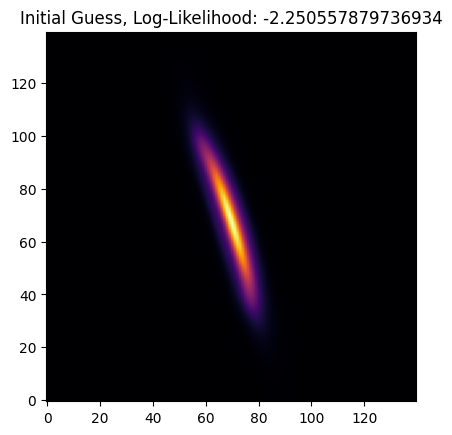

In [10]:
plt.imshow(opt.get_model(), origin='lower', cmap='inferno')
plt.title(f"Initial Guess, Log-Likelihood: {opt.log_likelihood(target_image, err_map)}")

In [11]:
opt.print_params()

Disk Params: {'accuracy': 0.005, 'alpha_in': 5, 'alpha_out': -5, 'sma': 51.0, 'e': 0.0, 'ksi0': 3.0, 'gamma': 2.0, 'beta': 1.0, 'rmin': 0.0, 'dens_at_r0': 1.0, 'inclination': 85.0, 'position_angle': 17.5, 'x_center': 70.0, 'y_center': 70.0, 'halfNbSlices': 25, 'omega': 0.0}
SPF Params: {'backscatt_bound': Array(-0.9961947, dtype=float64, weak_type=True), 'forwardscatt_bound': Array(0.9961947, dtype=float64, weak_type=True), 'num_knots': 5, 'knot_values': Array([10.92984453,  2.1434956 ,  1.        ,  0.60466746,  0.41513937],      dtype=float64)}
PSF Params: {'scale_factor': 1.0, 'offset': 1.0}
Stellar PSF Params: None
Misc Params: {'distance': 109.62, 'pxInArcsec': 0.01414, 'nx': 140, 'ny': 140, 'halfNbSlices': 25, 'flux_scaling': Array(180.79827555, dtype=float64)}


JAX can be particularly troublesome with NaNs and infinities, as it does not handle them as Numpy does---the below functions can be enabled to help debug JAX errors that may arise.

In [12]:
# Can enable these to debug jax issues
# jax.config.update('jax_debug_nans', True)
# jax.config.update('jax_debug_infs', True)

### Running Optimization

With the `optimizer` class, it is straightforward to fit for different parameters using `fit_keys`. Here you can use any of the keywords from `disk_params` and/or `spf_params`. It is also possible to fit for the logarithm of any given parameter using `logscaled_params`, which is useful for parameters that may span orders of magnitude (such as `knot_values`) or that may be very close to zero (such as `e`). If using the Spline SPF, it is also necessary to specify that that keyword will be given as an array (as opposed to a single value) with `array_params`.

Before running an MCMC, it is often helpful to use `scipy.optimize` to get your starting parameters to save on time and burn-in for the MCMC.

In [23]:
# Logscaling helps for fitting across orders of magnitude

fit_keys = ['alpha_in', 'alpha_out', 'sma', 'inclination', 'position_angle', 'x_center', 'y_center', 'knot_values', 'e','beta']
logscaled_params = ['knot_values']
array_params = ['knot_values']
bounds = ([0.1, -15, 0, 0, 0, 60, 60, np.zeros(opt.spf_params["num_knots"]), 0],
          [20, -0.1, 150, 180, 400, 80, 80, 1e4*np.ones(opt.spf_params["num_knots"]), 1])

opt.scipy_bounded_optimize(fit_keys, bounds, logscaled_params, array_params, target_image, err_map, use_grad = True, disp_soln = True, iters = 2000)
optimal_image = opt.get_model()

ValueError: The number of bounds is not compatible with the length of `x0`.

### Results

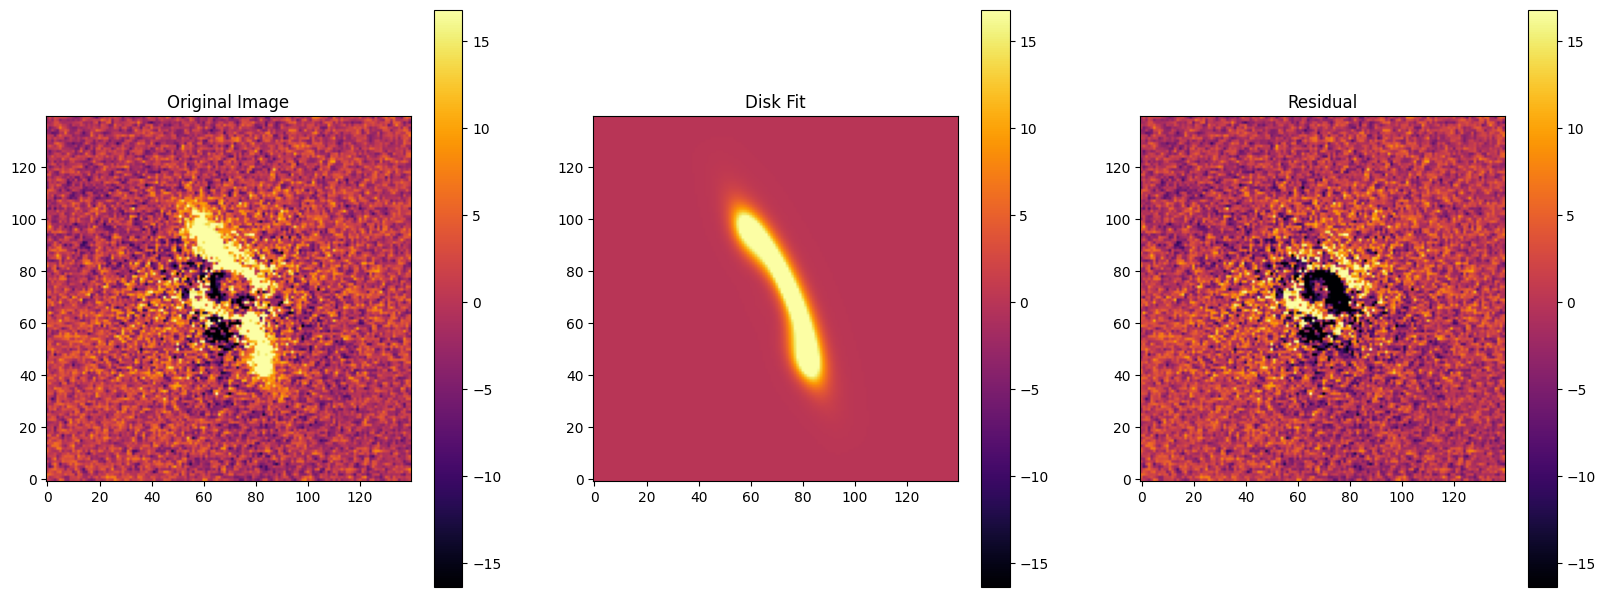

In [14]:
fig, axes = plt.subplots(1,3, figsize=(20,10))

mask = OptimizeUtils.get_mask(target_image)
vmin = np.nanpercentile(target_image[mask], 10)
vmax = np.nanpercentile(target_image[mask], 90)

im = axes[0].imshow(target_image, origin='lower', cmap='inferno')
axes[0].set_title("Original Image")
plt.colorbar(im, ax=axes[0], shrink=0.75)
im.set_clim(vmin, vmax)

im = axes[1].imshow(optimal_image, origin='lower', cmap='inferno')
axes[1].set_title("Disk Fit")
plt.colorbar(im, ax=axes[1], shrink=0.75)
im.set_clim(vmin, vmax)

im = axes[2].imshow(target_image-optimal_image, origin='lower', cmap='inferno')
axes[2].set_title("Residual")
plt.colorbar(im, ax=axes[2], shrink=0.75)
im.set_clim(vmin, vmax)

Another key function for the Spline SPF is `opt.scale_spline_to_fixed_point`---the spline's absolute value and the flux scaling are degenerate, so to compare directly between various disks, we scale each spline to a value of 1 at 90 degrees. This function not only performs that spline scaling, but also adjusts the value of `flux_scaling` accordingly to preserve the best fit disk in the `optimizer` class.

In [15]:
opt.scale_spline_to_fixed_point(0, 1)
opt.print_params()

Disk Params: {'accuracy': 0.005, 'alpha_in': np.float64(3.2376717285998615), 'alpha_out': np.float64(-7.16778888626926), 'sma': np.float64(48.229633123909075), 'e': np.float64(0.0), 'ksi0': 3.0, 'gamma': 2.0, 'beta': 1.0, 'rmin': 0.0, 'dens_at_r0': 1.0, 'inclination': np.float64(77.57994965232862), 'position_angle': np.float64(24.229927498917668), 'x_center': np.float64(72.74500963080379), 'y_center': np.float64(73.2165305083786), 'halfNbSlices': 25, 'omega': 0.0}
SPF Params: {'backscatt_bound': Array(-0.9961947, dtype=float64, weak_type=True), 'forwardscatt_bound': Array(0.9961947, dtype=float64, weak_type=True), 'num_knots': 5, 'knot_values': Array([1.76080236, 1.22957421, 1.        , 0.33870276, 0.01932145],      dtype=float64)}
PSF Params: {'scale_factor': 1.0, 'offset': 1.0}
Stellar PSF Params: None
Misc Params: {'distance': 109.62, 'pxInArcsec': 0.01414, 'nx': 140, 'ny': 140, 'halfNbSlices': 25, 'flux_scaling': Array(1407.8336355, dtype=float64)}


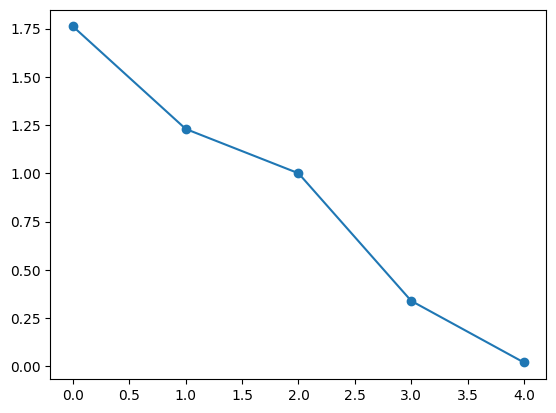

In [18]:
plt.plot(opt.spf_params["knot_values"], marker='o')

## Running MCMC

For MCMC, we recommend that the spline values are log scaled. The `optimizer` class passes them in as a logarithm and they are exponated in the lambda expression, which evens out the Markov Chains, helping MCMC work more efficiently.

As MCMCs can take significant time to run, the chain is saved during the run using `emcee`'s hdf5 backend functionality. There is also a built-in safety check that requires keyboard input (`y` for yes, `n` for no) to confirm you would like to proceed before overwriting an existing backend. The default name of this backend file is `test_emcee_backend.h5`--to change the name, set `opt.name` to your preferred value, and this will be appended with `_emcee_backend.h5`

The chain used in this tutorial is ***far*** too short for reliable parameter estimation, and instead is provided only to show the workflow of disk modeling with GRaTer-JAX. We recommend taking a look at `emcee`'s documentation for MCMC diagnostics and convergence to determine your number of burn-in steps and total chain length.

In [ ]:
fit_keys = ['alpha_in', 'alpha_out', 'sma', 'inclination', 'position_angle', 'x_center', 'y_center', 'knot_values', 'e','beta']
logscaled_params = ['knot_values']
array_params = ['knot_values']
bounds = ([0.1, -15, 0, 0, 0, 60, 60, np.zeros(opt.spf_params["num_knots"]), 0],
          [200, -0.1, 150, 180, 400, 80, 80, 1e4*np.ones(opt.spf_params["num_knots"]), 1])

mc_model = opt.mcmc(fit_keys, logscaled_params, array_params, target_image, err_map, bounds, nwalkers=100, niter=100, burns=20)


Running burn-in...


  0%|          | 0/20 [00:00<?, ?it/s]/home/blewis/anaconda3/envs/graterjax_new/lib/python3.10/site-packages/emcee/moves/red_blue.py:99: RuntimeWarning: invalid value encountered in scalar subtract
  lnpdiff = f + nlp - state.log_prob[j]
100%|██████████| 20/20 [00:08<00:00,  2.38it/s]


Running production...


100%|██████████| 100/100 [00:39<00:00,  2.53it/s]


The function `model_obj.get_theta_median` will return the median parameters as estimated by the MCMC. Setting `scaled = True` will return the scaled spline SPF values.

In [20]:
mc_soln = mc_model.get_theta_median(scaled = True)
img = opt.get_model()

Text(0.5, 1.0, 'Post MCMC Residuals')

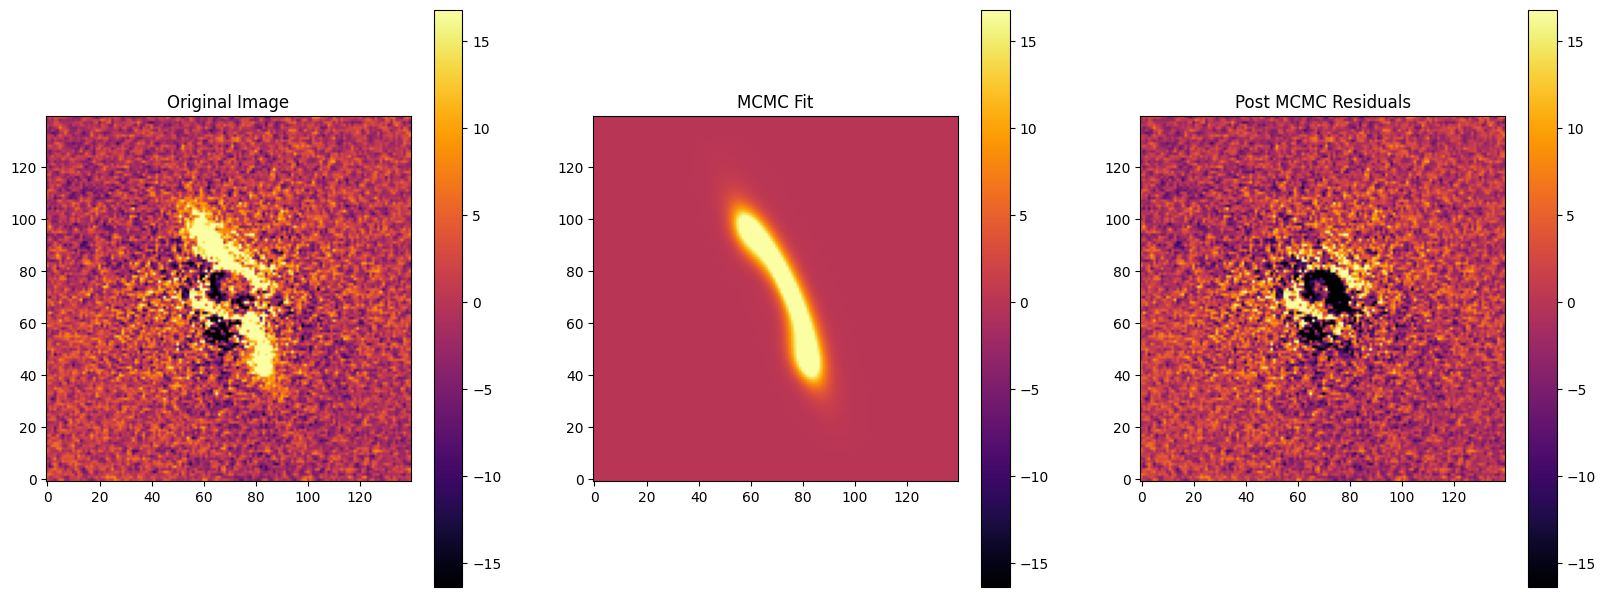

In [21]:
fig, axes = plt.subplots(1,3, figsize=(20,10))

mask = OptimizeUtils.get_mask(target_image)
vmin = np.nanpercentile(target_image[mask], 10)
vmax = np.nanpercentile(target_image[mask], 90)

im = axes[0].imshow(target_image, origin='lower', cmap='inferno')
axes[0].set_title("Original Image")
plt.colorbar(im, ax=axes[0], shrink=0.75)
im.set_clim(vmin, vmax)

im = axes[1].imshow(img, origin='lower', cmap='inferno')
axes[1].set_title("MCMC Fit")
plt.colorbar(im, ax=axes[1], shrink=0.75)
im.set_clim(vmin, vmax)

im = axes[2].imshow(target_image-img, origin='lower', cmap='inferno')
axes[2].set_title("Residual")
plt.colorbar(im, ax=axes[2], shrink=0.75)
im.set_clim(vmin, vmax)
plt.title("Post MCMC Residuals")

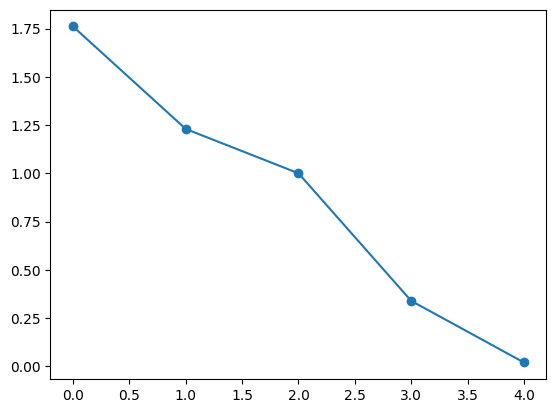

In [22]:
plt.plot(opt.spf_params["knot_values"], marker='o')

### Plotting MCMC Results

Various MCMC diagnostics are incorporated into the `optimizer` class, such as viewing the MCMC chains and creating a corner plot with [`corner.py`](https://corner.readthedocs.io/en/latest/). Again, you can use the boolean keyword `scaled` to scale the spline SPF chains and resulting parameters automatically. Labels for the chains must be entered, and are almost equivalent to the `fit_keys` list, except for any array-like parameters (e.g. the knot values).

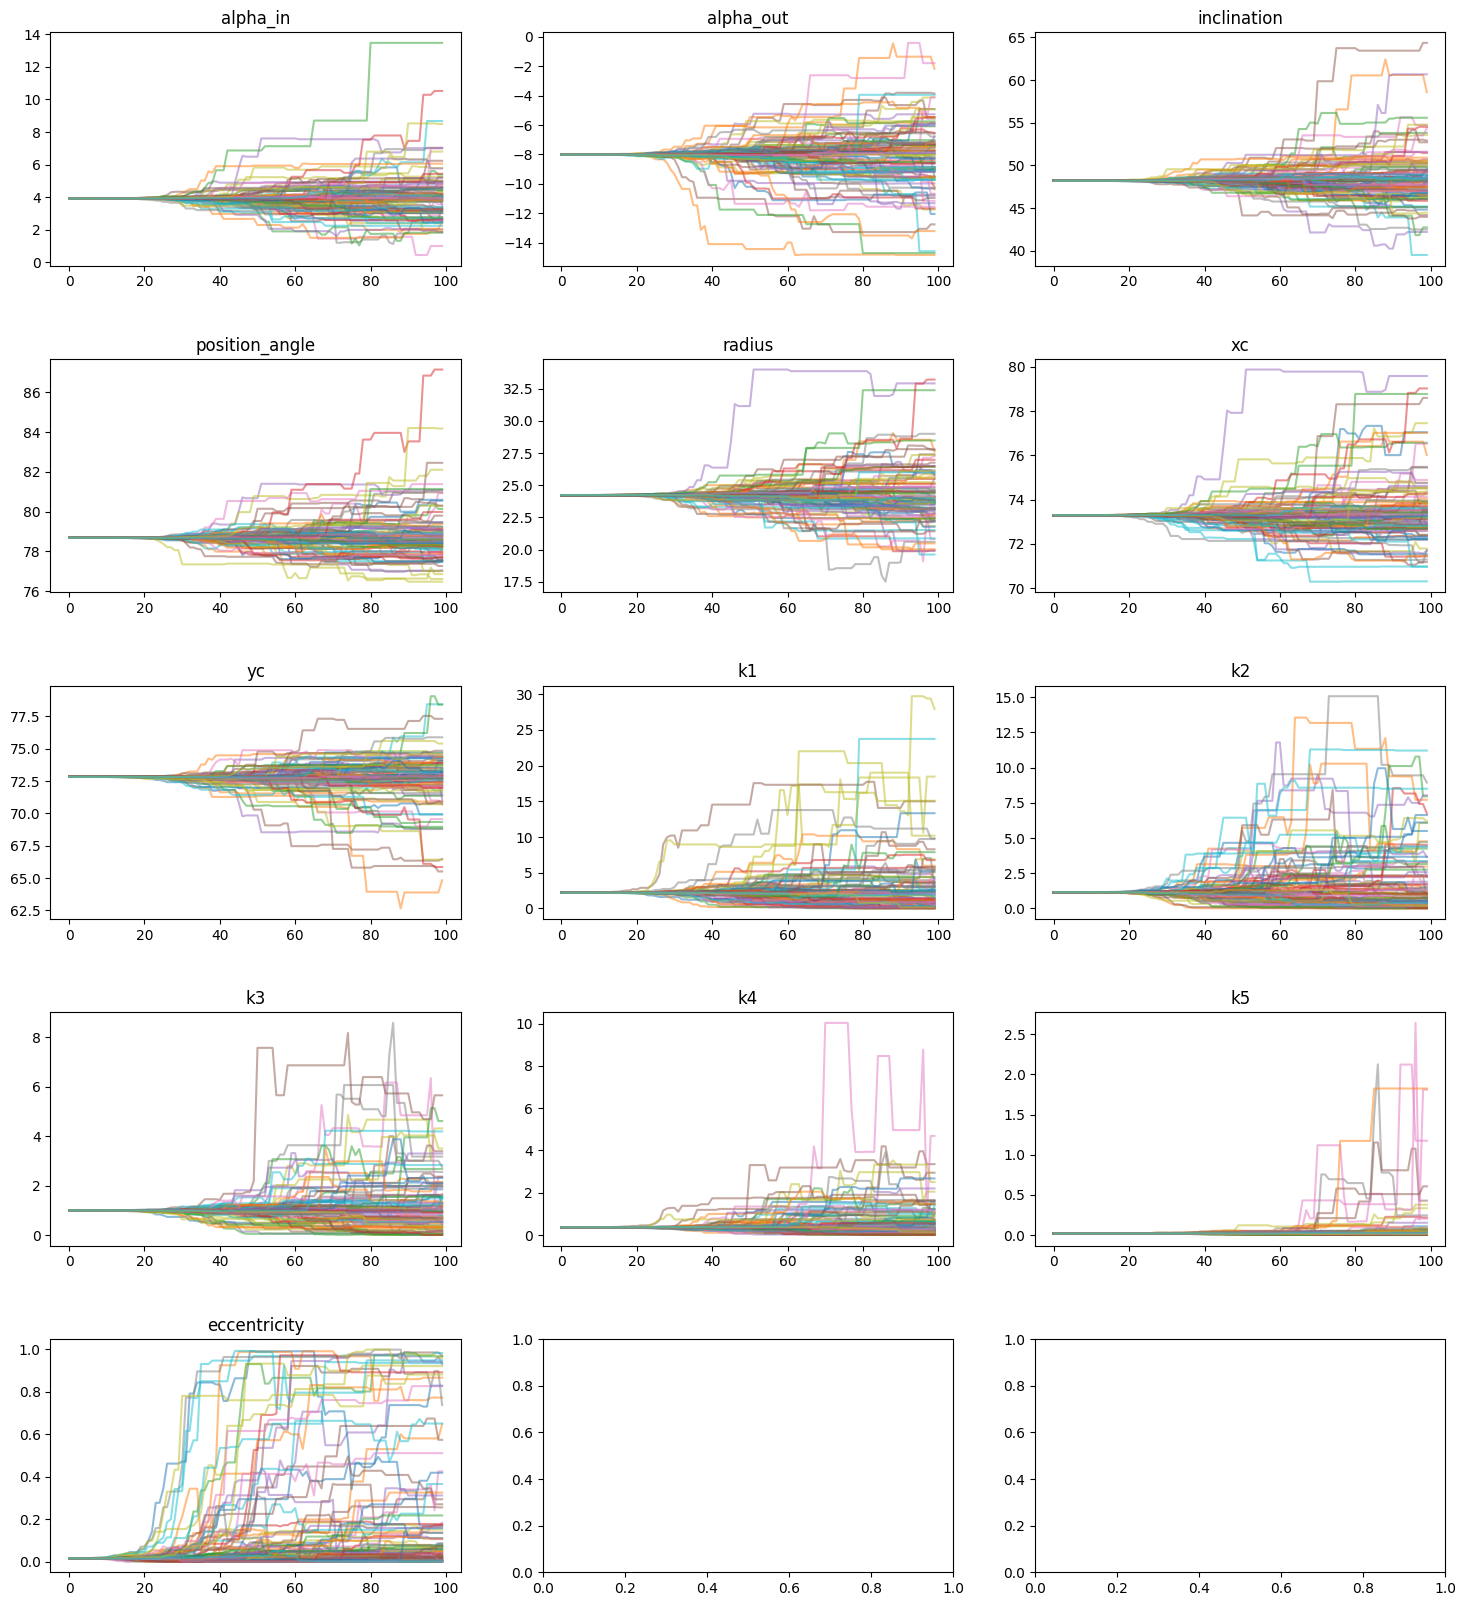

In [29]:
labels = ['alpha_in', 'alpha_out', 'inclination', 'position_angle', 'radius', 'xc', 'yc']
for i in range(0, opt.spf_params['num_knots']):
    labels.append('k'+str(i+1))
labels.append('eccentricity')
mc_model.plot_chains(labels, scaled = True)

### Corner Plot

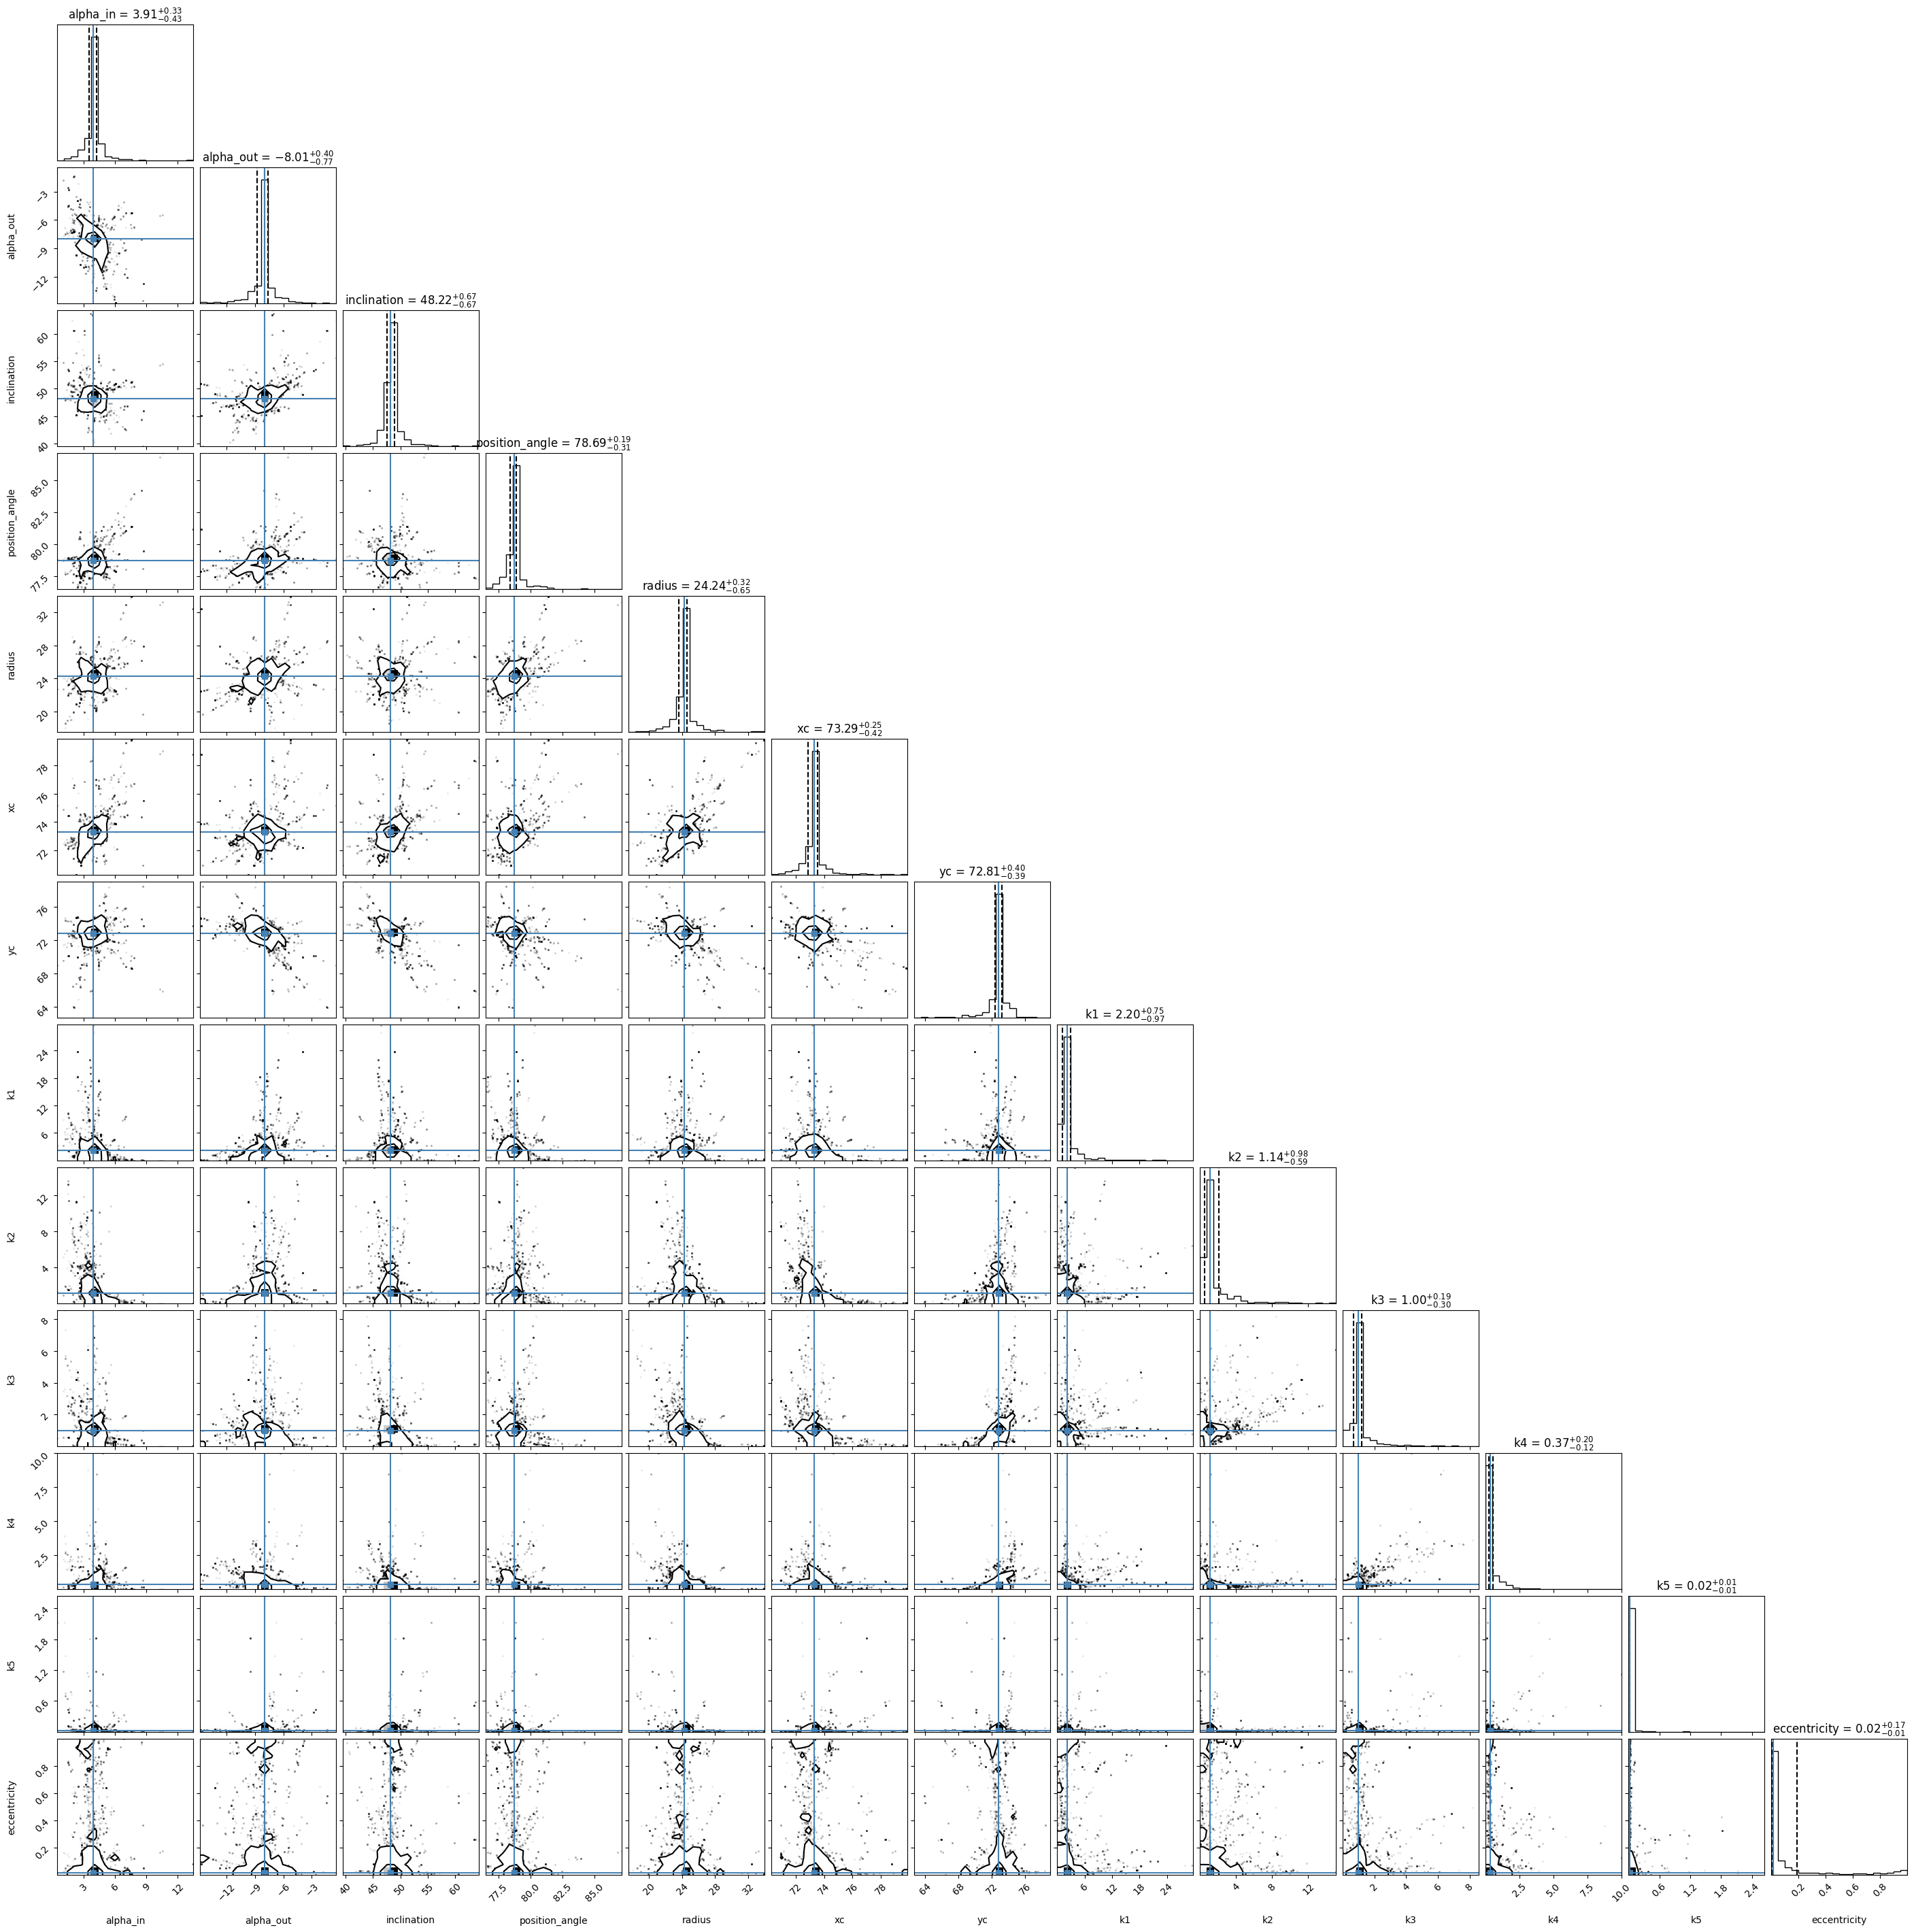

In [30]:
fig = mc_model.show_corner_plot(labels, truths=mc_soln, scaled = True, quiet = True)

In [32]:
print(dict(zip(labels, mc_model.get_theta_median(scaled = True))))

{'alpha_in': np.float64(3.909570219710574), 'alpha_out': np.float64(-8.009515682825988), 'inclination': np.float64(48.215433766465864), 'position_angle': np.float64(78.6871840137304), 'radius': np.float64(24.238525393656566), 'xc': np.float64(73.29324825333009), 'yc': np.float64(72.81198560586489), 'k1': np.float64(2.1967082116962056), 'k2': np.float64(1.1411696207146491), 'k3': np.float64(0.9998884497731928), 'k4': np.float64(0.36506654738408184), 'k5': np.float64(0.019043359925446746), 'eccentricity': np.float64(0.016461791174933203)}
